# Merging holes: `merge_holes` and overlapping donuts

Smoothify smooths a polygon's exterior shell and each interior hole independently.
Two options control how holes interact before smoothing:

- **`merge_holes`** (default `True`): holes *within one polygon* that touch or
  nearly touch (e.g. diagonally adjacent raster cells) are joined first, so they
  smooth into one coherent opening instead of two overlapping blobs.
- **`merge_collection`** (default `True`): adjacent/overlapping *features* are
  dissolved first. A region stays open only where **no** feature has material,
  so overlapping donuts resolve their holes by union semantics — and any
  openings that survive then go through `merge_holes` per merged polygon.

This notebook walks through both, ending with the overlapping-donut case.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import unary_union

from smoothify import smoothify


def plot_result(ax, original, smoothed, title):
    gpd.GeoSeries([original]).boundary.plot(ax=ax, color="0.6", linewidth=1)
    gpd.GeoSeries([smoothed]).plot(ax=ax, color="lightgreen", alpha=0.7)
    gpd.GeoSeries([smoothed]).boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_aspect("equal")


def hole_count(geom):
    polys = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
    return sum(len(p.interiors) for p in polys)

## 1. Corner-touching holes within one polygon

Two holes from diagonally adjacent raster cells share a corner. Smoothed
independently (`merge_holes=False`) they become two rounded openings separated
by a fake land bridge; with the default `merge_holes=True` they smooth into a
single opening.

`segment_length` is kept much smaller than the holes — it is the scale of
detail that gets smoothed away, so it should match the raster pixel size, not
the feature size.

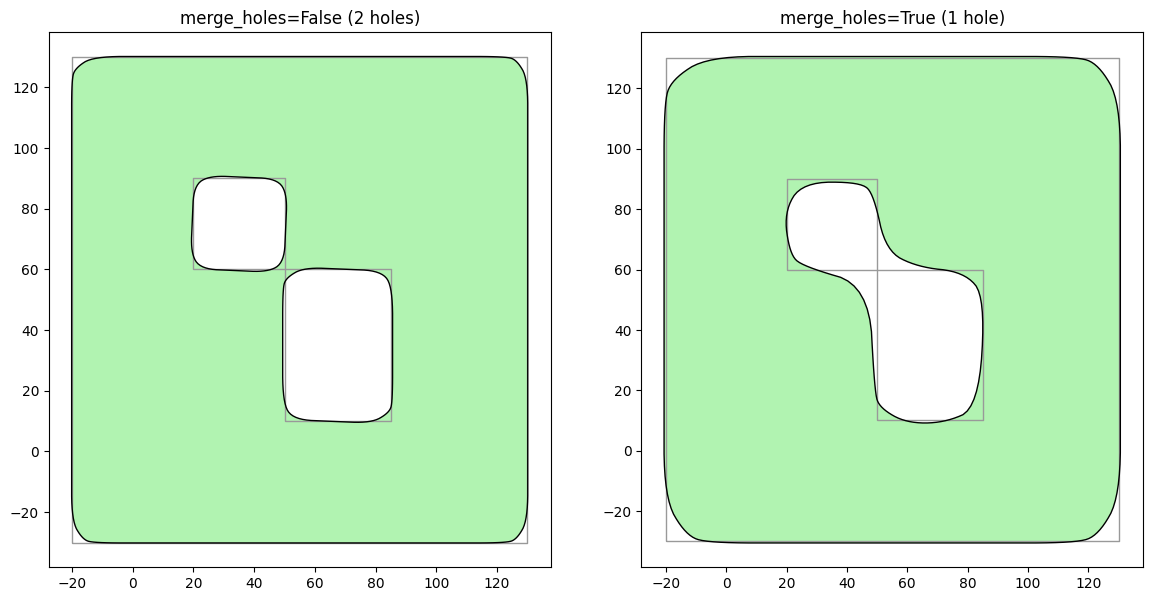

In [2]:
hole_a = [(20, 60), (50, 60), (50, 90), (20, 90)]
hole_b = [(50, 10), (85, 10), (85, 60), (50, 60)]  # shares corner (50, 60)
shell = Polygon([(-20, -30), (130, -30), (130, 130), (-20, 130)], [hole_a, hole_b])

merged = smoothify(shell, segment_length=10.0)
separate = smoothify(shell, segment_length=5.0, merge_holes=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_result(
    axes[0], shell, separate, f"merge_holes=False ({hole_count(separate)} holes)"
)
plot_result(axes[1], shell, merged, f"merge_holes=True ({hole_count(merged)} hole)")
plt.tight_layout()
plt.show()

## 2. Overlapping donuts, dissolved (`merge_collection=True`, the default)

Holes of two *separate* features **can** overlap — picture two overlapping
donuts. With `merge_collection=True` the features are dissolved first, and the
union keeps a region open only where **neither** donut has material.

For these two square donuts that leaves three openings: a sliver of each
original hole, plus the middle where the holes overlap. They are separated by
real material, so `merge_holes` correctly leaves them as three distinct
openings.

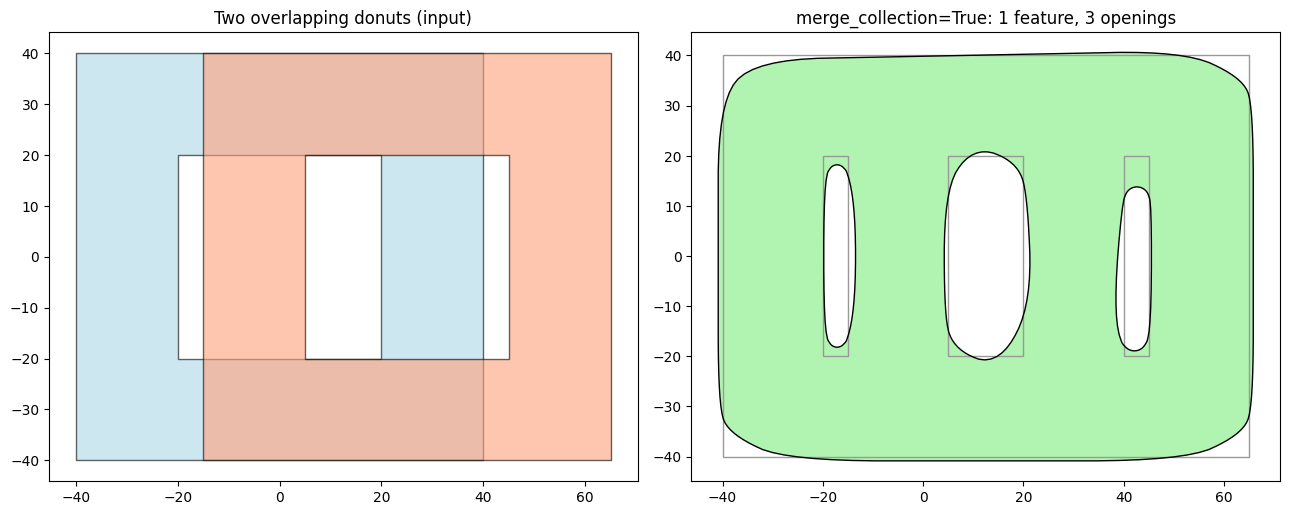

In [3]:
def donut(cx, outer=40, inner=20):
    return Polygon(
        [
            (cx - outer, -outer),
            (cx + outer, -outer),
            (cx + outer, outer),
            (cx - outer, outer),
        ],
        [
            [
                (cx - inner, -inner),
                (cx + inner, -inner),
                (cx + inner, inner),
                (cx - inner, inner),
            ]
        ],
    )


donut_a, donut_b = donut(0), donut(25)
gdf_donuts = gpd.GeoDataFrame(geometry=[donut_a, donut_b])

dissolved = smoothify(gdf_donuts, segment_length=10.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
gpd.GeoDataFrame(geometry=[donut_a, donut_b]).plot(
    ax=axes[0], color=["lightblue", "lightsalmon"], alpha=0.6, edgecolor="black"
)
axes[0].set_title("Two overlapping donuts (input)")
axes[0].set_aspect("equal")

plot_result(
    axes[1],
    unary_union([donut_a, donut_b]),
    dissolved.geometry.iloc[0],
    f"merge_collection=True: {len(dissolved)} feature, "
    f"{hole_count(dissolved.geometry.iloc[0])} openings",
)
plt.tight_layout()
plt.show()

## 3. Overlapping donuts, kept separate (`merge_collection=False`)

Without the dissolve, each donut stays its own feature: each is smoothed
independently with its own hole, and the outputs still overlap. Smoothify does
not resolve overlap you have told it not to merge — and `merge_holes` only
ever operates within a single polygon, so holes of separate features never
interact in this mode.

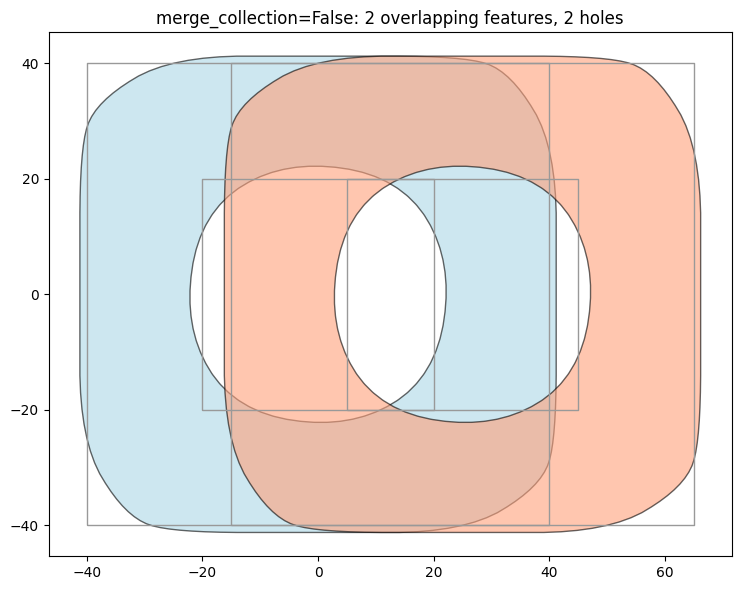

In [4]:
kept_separate = smoothify(gdf_donuts, segment_length=10.0, merge_collection=False)

fig, ax = plt.subplots(figsize=(8, 6))
kept_separate.plot(
    ax=ax, color=["lightblue", "lightsalmon"], alpha=0.6, edgecolor="black"
)
gpd.GeoDataFrame(geometry=[donut_a, donut_b]).boundary.plot(
    ax=ax, color="0.6", linewidth=1
)
ax.set_title(
    f"merge_collection=False: {len(kept_separate)} overlapping features, "
    f"{sum(hole_count(g) for g in kept_separate.geometry)} holes"
)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Holes split across features, reunited by the dissolve

Holes of separate polygons can never *touch* when the features merely abut
(there is always shell material between them) — but a hole that polygonization
split across a boundary shows up as matching edge-notches on the two shells.
The dissolve reunites those notches into one interior ring, and because
`merge_holes` runs per polygon *after* the dissolve, the reunited hole then
merges with any pre-existing hole it touches.

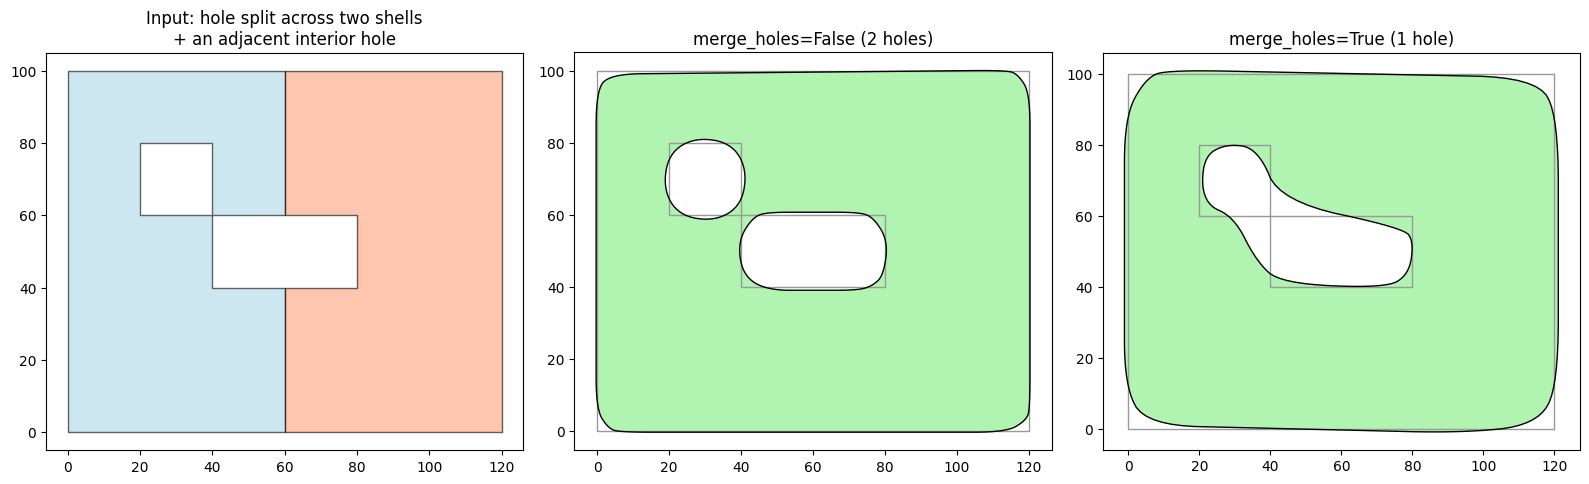

In [5]:
# Left shell: a bay notch on its right edge plus an interior hole
# corner-touching that notch at (40, 60). Right shell: the matching notch.
left = Polygon(
    [(0, 0), (60, 0), (60, 40), (40, 40), (40, 60), (60, 60), (60, 100), (0, 100)],
    [[(20, 60), (40, 60), (40, 80), (20, 80)]],
)
right = Polygon(
    [(60, 0), (120, 0), (120, 100), (60, 100), (60, 60), (80, 60), (80, 40), (60, 40)]
)
gdf_split = gpd.GeoDataFrame(geometry=[left, right])

reunited = smoothify(gdf_split, segment_length=10.0)
not_merged = smoothify(gdf_split, segment_length=5.0, merge_holes=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
gdf_split.plot(
    ax=axes[0], color=["lightblue", "lightsalmon"], alpha=0.6, edgecolor="black"
)
axes[0].set_title("Input: hole split across two shells\n+ an adjacent interior hole")
axes[0].set_aspect("equal")

src = unary_union([left, right])
plot_result(
    axes[1],
    src,
    not_merged.geometry.iloc[0],
    f"merge_holes=False ({hole_count(not_merged.geometry.iloc[0])} holes)",
)
plot_result(
    axes[2],
    src,
    reunited.geometry.iloc[0],
    f"merge_holes=True ({hole_count(reunited.geometry.iloc[0])} hole)",
)
plt.tight_layout()
plt.show()

## Summary

With identical flags the outcome depends on the geometry: `merge_holes` only
joins openings that actually touch (or nearly touch) within one output
polygon.

| Scenario | `merge_collection` | `merge_holes` | Result |
|---|---|---|---|
| Touching holes in one polygon | `True` (default) | `True` (default) | One smooth opening |
| Touching holes in one polygon | `True` (default) | `False` | Separate openings, fake land bridge |
| Overlapping donuts | `True` (default) | `True` (default) | One feature; only truly open regions stay holes. The three openings are separated by real material, so `merge_holes` has nothing to join |
| Overlapping donuts | `False` | `True` (default) | Separate overlapping features; holes of different features never interact |
| Hole split across features, touching another hole | `True` (default) | `True` (default) | The dissolve reunites the split hole into one polygon, where it now touches the other hole — so `merge_holes` joins them |

`merge_holes` joins openings *within each output polygon*; `merge_collection`
decides what an output polygon is — including resolving overlapping shells and
holes by union before hole-merging happens.